# Notebook 2: Visualizing the Value Premium

In this notebook we create three charts that tell the core story of our project:
- Do value stocks earn higher average returns than growth stocks?
- How did $1,000 invested in value vs. growth grow over time?
- Has the value premium gotten weaker in recent years?

Data is loaded from the CSV files saved in Notebook 1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# Load the cleaned data we saved in Notebook 1
bm_wide = pd.read_csv('bm_wide.csv', index_col='date', parse_dates=True)
ep_wide = pd.read_csv('ep_wide.csv', index_col='date', parse_dates=True)

print("BM date range:", bm_wide.index.min(), "to", bm_wide.index.max())
print("EP date range:", ep_wide.index.min(), "to", ep_wide.index.max())

BM date range: 1951-07-31 00:00:00 to 2024-12-31 00:00:00
EP date range: 1951-01-31 00:00:00 to 2024-12-31 00:00:00


### Chart 1: Average Monthly Returns by Quintile

This bar chart shows the average monthly return for each quintile group.
If value investing works, we should see a clear pattern where Q5 (value) 
has higher average returns than Q1 (growth).

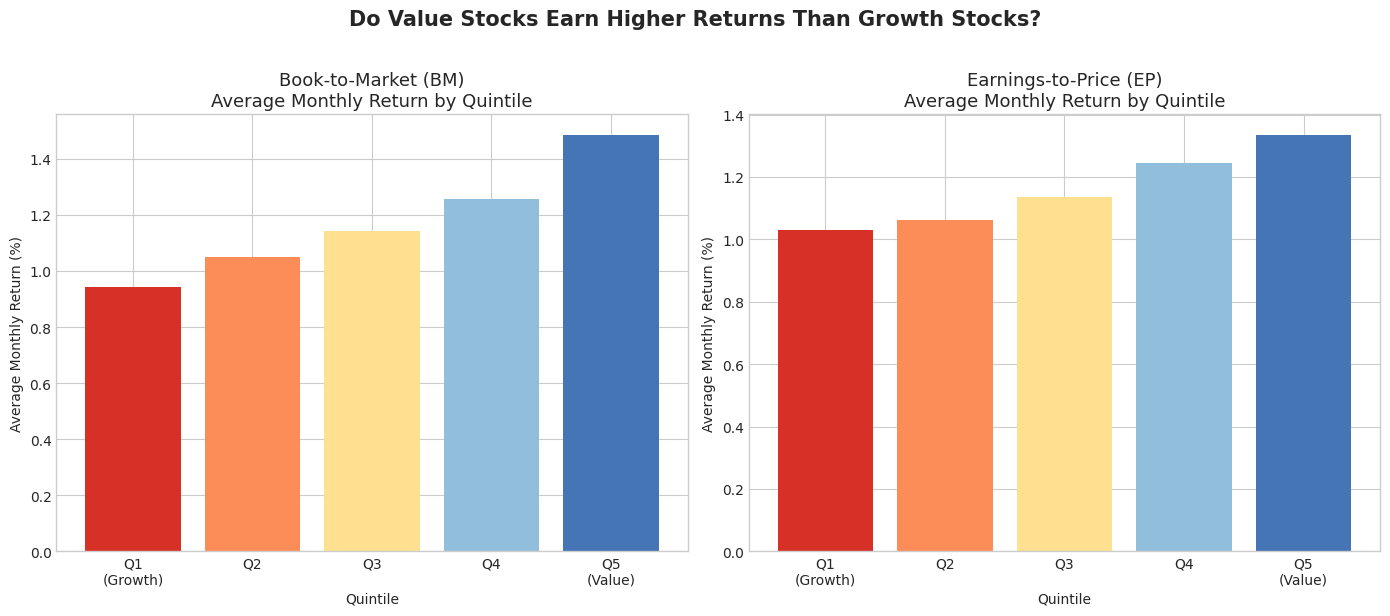

In [3]:
bm_avg = bm_wide[['Q1','Q2','Q3','Q4','Q5']].mean()
ep_avg = ep_wide[['Q1','Q2','Q3','Q4','Q5']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4']
ax1.bar(['Q1\n(Growth)','Q2','Q3','Q4','Q5\n(Value)'], bm_avg, color=colors)
ax1.set_title('Book-to-Market (BM)\nAverage Monthly Return by Quintile', fontsize=13)
ax1.set_ylabel('Average Monthly Return (%)')
ax1.set_xlabel('Quintile')

ax2.bar(['Q1\n(Growth)','Q2','Q3','Q4','Q5\n(Value)'], ep_avg, color=colors)
ax2.set_title('Earnings-to-Price (EP)\nAverage Monthly Return by Quintile', fontsize=13)
ax2.set_ylabel('Average Monthly Return (%)')
ax2.set_xlabel('Quintile')

plt.suptitle('Do Value Stocks Earn Higher Returns Than Growth Stocks?', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_bar.png', bbox_inches='tight', dpi=150)
plt.show()

### Chart 2: Cumulative Returns: Value vs. Growth

This chart shows how $1,000 invested in Q1 (growth) vs Q5 (value) would have 
grown over time. It also shows the long-short spread (buying value, shorting growth).
If value investing works, the Q5 line should end up higher than Q1.

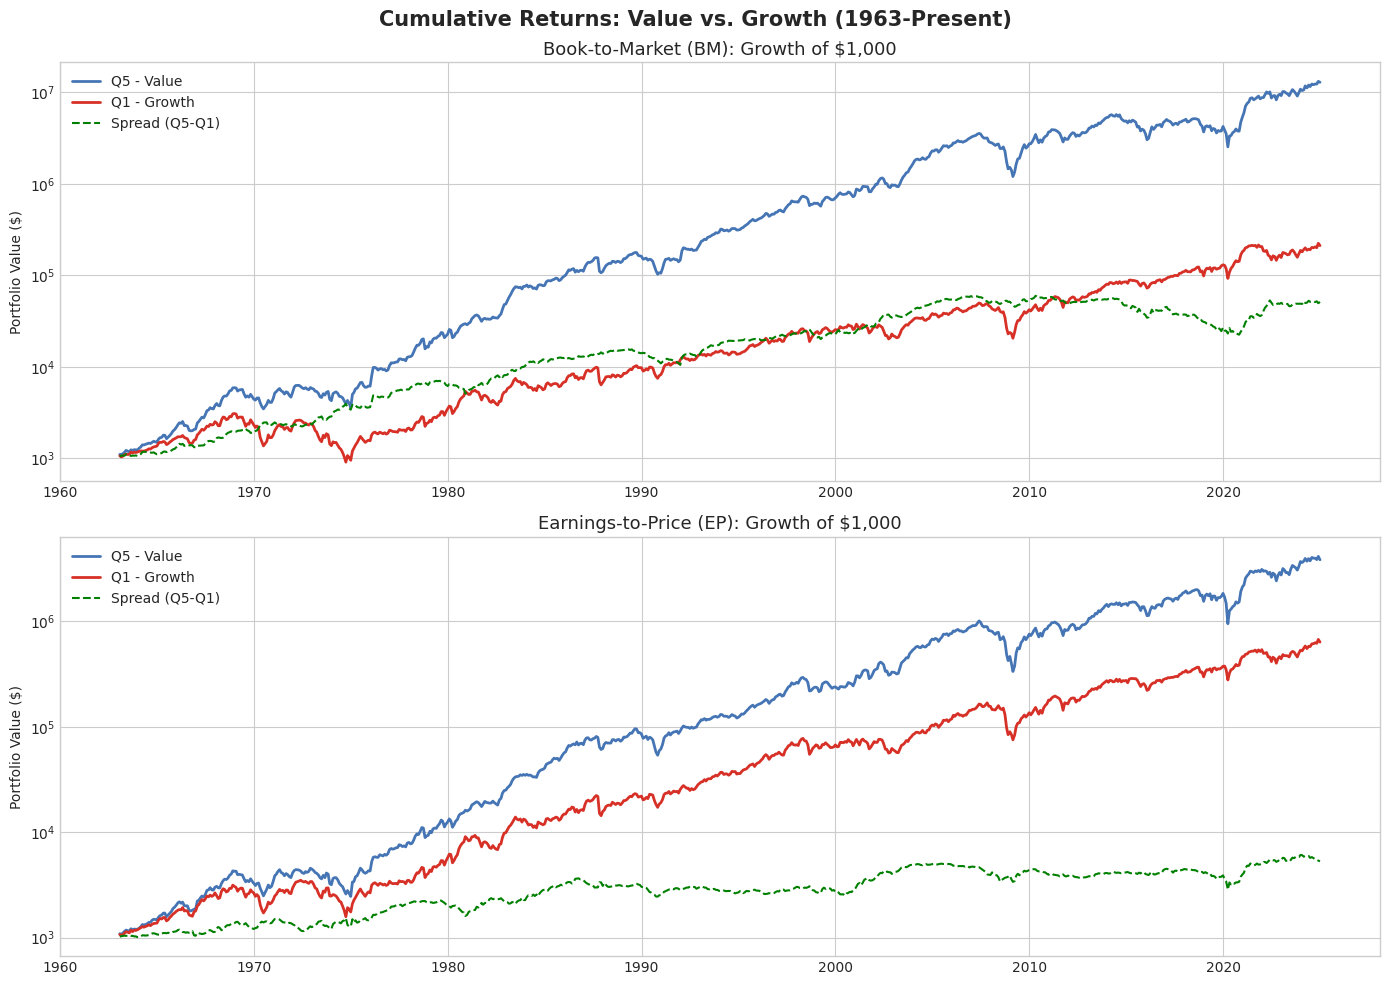

In [4]:
start = '1963-01-01'
bm_filtered = bm_wide[bm_wide.index >= start].copy()
ep_filtered = ep_wide[ep_wide.index >= start].copy()

bm_cum = (1 + bm_filtered[['Q1','Q5','spread']] / 100).cumprod() * 1000
ep_cum = (1 + ep_filtered[['Q1','Q5','spread']] / 100).cumprod() * 1000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(bm_cum.index, bm_cum['Q5'], label='Q5 - Value', color='#4575b4', linewidth=2)
ax1.plot(bm_cum.index, bm_cum['Q1'], label='Q1 - Growth', color='#d73027', linewidth=2)
ax1.plot(bm_cum.index, bm_cum['spread'], label='Spread (Q5-Q1)', 
         color='green', linewidth=1.5, linestyle='--')
ax1.set_title('Book-to-Market (BM): Growth of $1,000', fontsize=13)
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.set_yscale('log')

ax2.plot(ep_cum.index, ep_cum['Q5'], label='Q5 - Value', color='#4575b4', linewidth=2)
ax2.plot(ep_cum.index, ep_cum['Q1'], label='Q1 - Growth', color='#d73027', linewidth=2)
ax2.plot(ep_cum.index, ep_cum['spread'], label='Spread (Q5-Q1)', 
         color='green', linewidth=1.5, linestyle='--')
ax2.set_title('Earnings-to-Price (EP): Growth of $1,000', fontsize=13)
ax2.set_ylabel('Portfolio Value ($)')
ax2.legend()
ax2.set_yscale('log')

plt.suptitle('Cumulative Returns: Value vs. Growth (1963-Present)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_cumulative.png', bbox_inches='tight', dpi=150)
plt.show()

### Chart 3: Rolling 12-Month Returns: Has the Value Premium Weakened?

This chart shows the rolling 12-month return of the spread (Q5 minus Q1) over time.
A positive value means value beat growth that year. A negative value means growth won.
If the value premium has weakened recently, we should see more negative values after 2010.

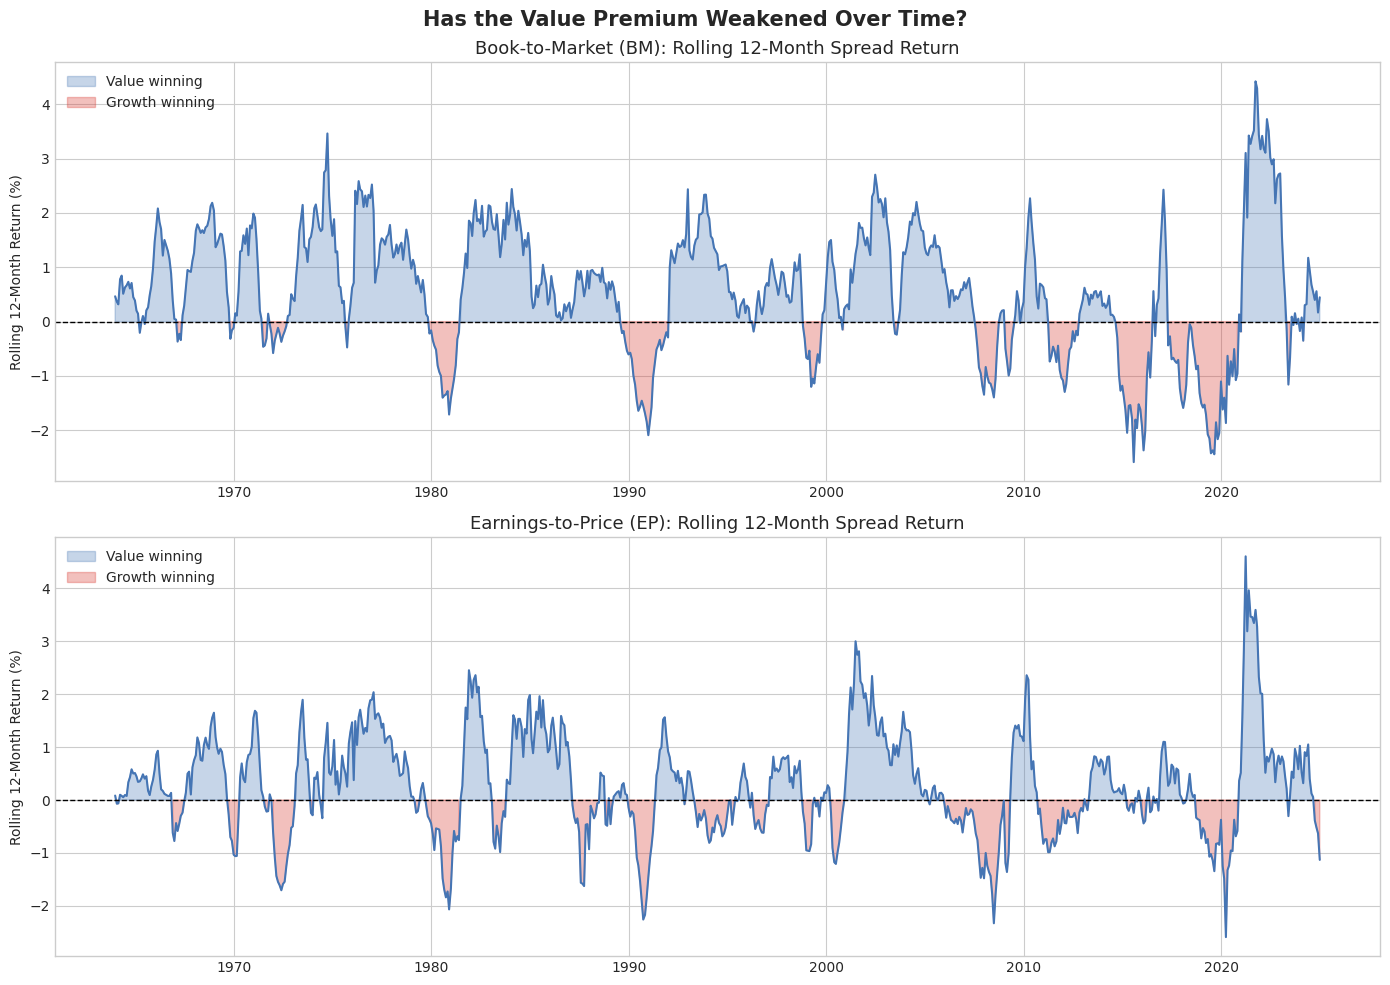

In [5]:
bm_rolling = bm_filtered['spread'].rolling(12).mean()
ep_rolling = ep_filtered['spread'].rolling(12).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(bm_rolling.index, bm_rolling, color='#4575b4', linewidth=1.5)
ax1.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax1.fill_between(bm_rolling.index, bm_rolling, 0,
                 where=(bm_rolling > 0), color='#4575b4', alpha=0.3, label='Value winning')
ax1.fill_between(bm_rolling.index, bm_rolling, 0,
                 where=(bm_rolling < 0), color='#d73027', alpha=0.3, label='Growth winning')
ax1.set_title('Book-to-Market (BM): Rolling 12-Month Spread Return', fontsize=13)
ax1.set_ylabel('Rolling 12-Month Return (%)')
ax1.legend()

ax2.plot(ep_rolling.index, ep_rolling, color='#4575b4', linewidth=1.5)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax2.fill_between(ep_rolling.index, ep_rolling, 0,
                 where=(ep_rolling > 0), color='#4575b4', alpha=0.3, label='Value winning')
ax2.fill_between(ep_rolling.index, ep_rolling, 0,
                 where=(ep_rolling < 0), color='#d73027', alpha=0.3, label='Growth winning')
ax2.set_title('Earnings-to-Price (EP): Rolling 12-Month Spread Return', fontsize=13)
ax2.set_ylabel('Rolling 12-Month Return (%)')
ax2.legend()

plt.suptitle('Has the Value Premium Weakened Over Time?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_rolling.png', bbox_inches='tight', dpi=150)
plt.show()